In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib 

import pandas as pd
import torch.nn as nn
import torch.optim as optim

import xarray as xr

import torch.nn as nn
import torch.optim as optim
import torch

from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

import seaborn as sns
import sklearn

# Load and preprocess data
We want to determine whether there is snow or not at the Folgefonna skisenter based on other variables

In [4]:
df = pd.read_csv('../lecture_exercises/data/folgefonna-skisenter_vaeret.csv', index_col=0)
df['Snow_presence'] = 1*(df.Snowdepth>0)
# df[['Tmin_d-1','Tmax_d-1','Tmean_d-1','wind_d-1','Pr_d-1']] = df[['Tmin','Tmax','Tmean','wind','Pr']].shift(1)
df=df.dropna()
X = df[['Tmin','wind']]
y = df['Snow_presence']

In [5]:
df

,Tmax,Tmean,Tmin,Pr,Snowdepth,wind,Snow_presence
date,,,,,,,
2015-10-01,5.2,3.5,2.2,1.0,0.0,6.1,0
2015-10-02,4.2,2.9,2.4,3.5,0.0,6.3,0
2015-10-03,4.5,2.4,-0.6,17.6,0.0,4.1,0
2015-10-04,3.4,2.5,1.7,0.6,0.0,1.6,0
2015-10-05,7.4,5.1,2.4,15.9,0.0,8.3,0
...,...,...,...,...,...,...,...
2025-09-04,10.5,8.0,7.0,22.0,0.0,6.1,0
2025-09-05,9.0,7.4,6.1,6.3,0.0,5.7,0
2025-09-06,8.9,6.7,4.0,6.5,0.0,2.1,0


(-20.0, 20.0)

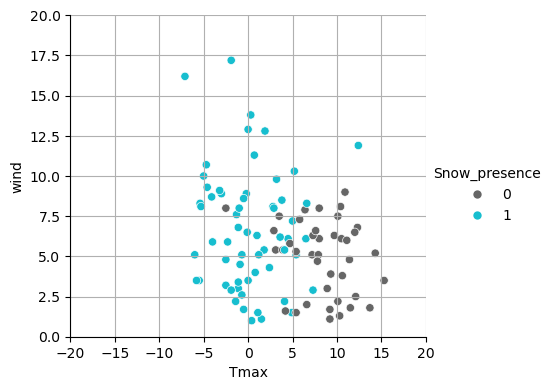

In [6]:
df_example = df.sample(100, random_state=35)
X_example = df_example[['Tmax','wind']]
y_example = df_example['Snow_presence']

plot = sns.relplot(df_example, x='Tmax',y='wind', hue='Snow_presence', height=4, aspect=1.1,palette=['.4','C9'])
plot.axes[0,0].grid()
plot.axes[0,0].set_ylim(0,20)
plot.axes[0,0].set_xlim(-20,20)


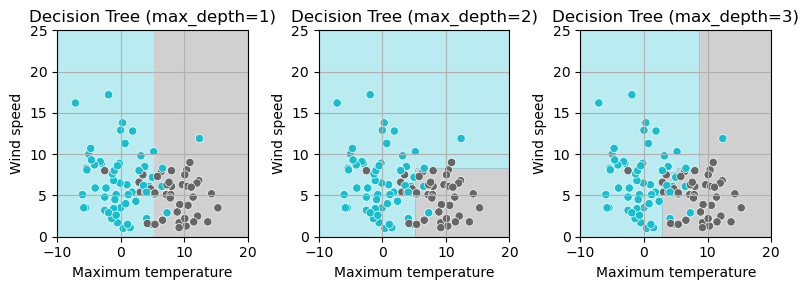

In [10]:
plt.figure(figsize=(8, 3))
x_min, x_max = -10,20
y_min, y_max = 0, 25
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
depths = [1, 2,3]
for i, depth in enumerate(depths, 1):
    clf = sklearn.tree.DecisionTreeClassifier(max_depth=depth, random_state=0)
    clf.fit(X_example.values, y_example.values)
    
    # Predict over the grid
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.subplot(1, 3, i)
    plt.contourf(xx, yy, Z, alpha=0.3,levels=[0,.5,1],colors=['.4','C9'])
    sns.scatterplot(df_example, x='Tmax',y='wind', hue='Snow_presence',palette=['.4','C9'])
    plt.title(f"Decision Tree (max_depth={depth})")
    plt.xlabel("Maximum temperature")
    plt.ylabel("Wind speed")
    plt.grid()
    plt.xlim(-10,20)
    plt.legend().remove()
plt.tight_layout()


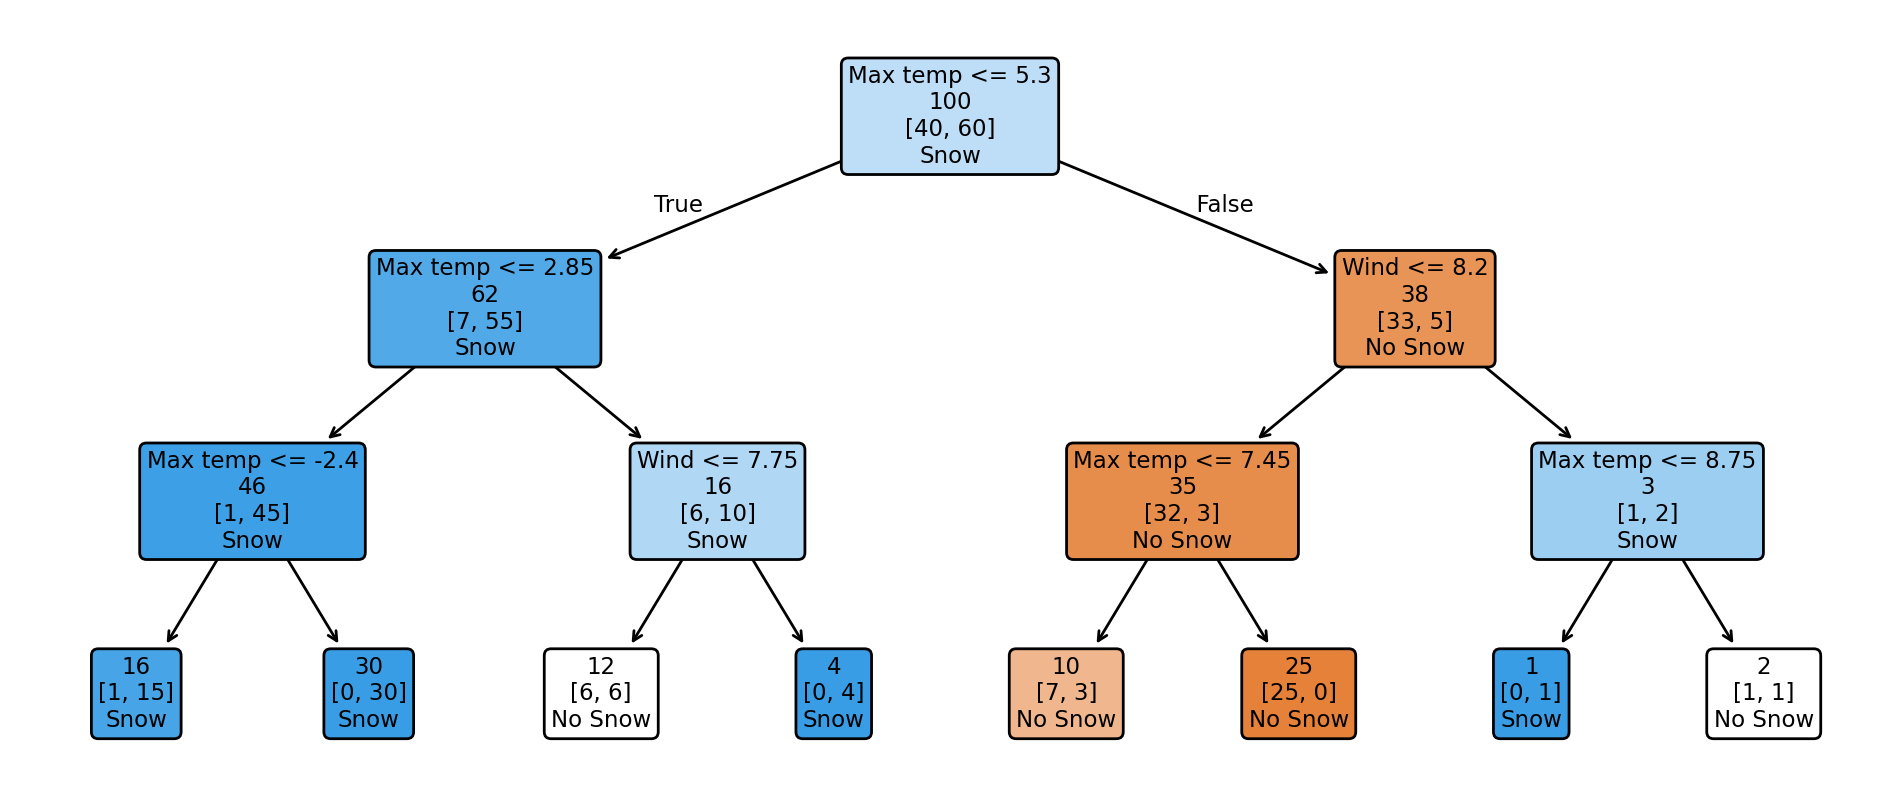

In [11]:
fig, axs = plt.subplots(figsize=(12,5),dpi=200)

sklearn.tree.plot_tree(clf,
                       rounded=True,
          filled=True,
               label='none',
          impurity=False,    # remove Gini/entropy
          proportion=False,  # show absolute sample counts
          feature_names=["Max temp", "Wind"],
          class_names=["No Snow", "Snow"],
                      );

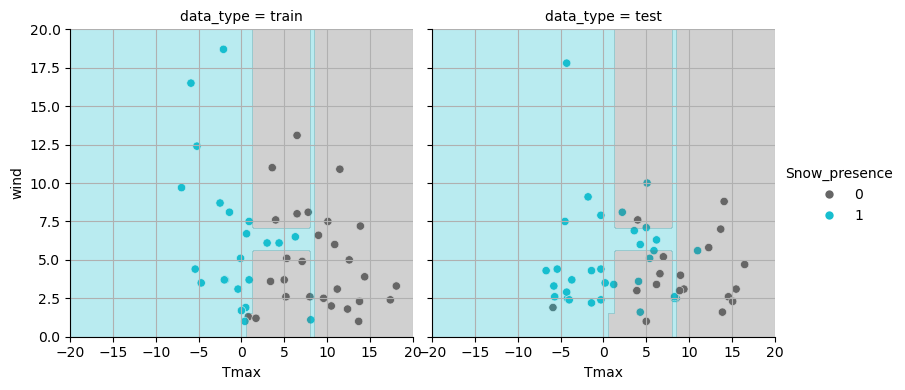

In [13]:
df_example = df.sample(50, random_state=19)
df_example['data_type'] = 'train'

df_test_example = df.sample(50, random_state=0)
df_test_example['data_type'] = 'test'
df_example_all = pd.concat([df_example, df_test_example])

X_example = df_example[['Tmax','wind']]
y_example = df_example['Snow_presence']

clf = sklearn.tree.DecisionTreeClassifier(max_depth=None, random_state=0)
clf.fit(X_example.values, y_example.values)

# Predict over the grid
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plot = sns.relplot(df_example_all, x='Tmax',y='wind', hue='Snow_presence', col='data_type',height=4, aspect=1,palette=['.4','C9'])
for ax in plot.axes.flat:
    ax.grid()
    ax.set_ylim(0,20)
    ax.set_xlim(-20,20)
    ax.contourf(xx, yy, Z, alpha=0.3,levels=[0,.5,1],colors=['.4','C9'])



# Split train and test
We split the data into two parts 

In [89]:
X_train, X_test, y_train, y_test = train_test_split(X,y,shuffle=True)

# Define model

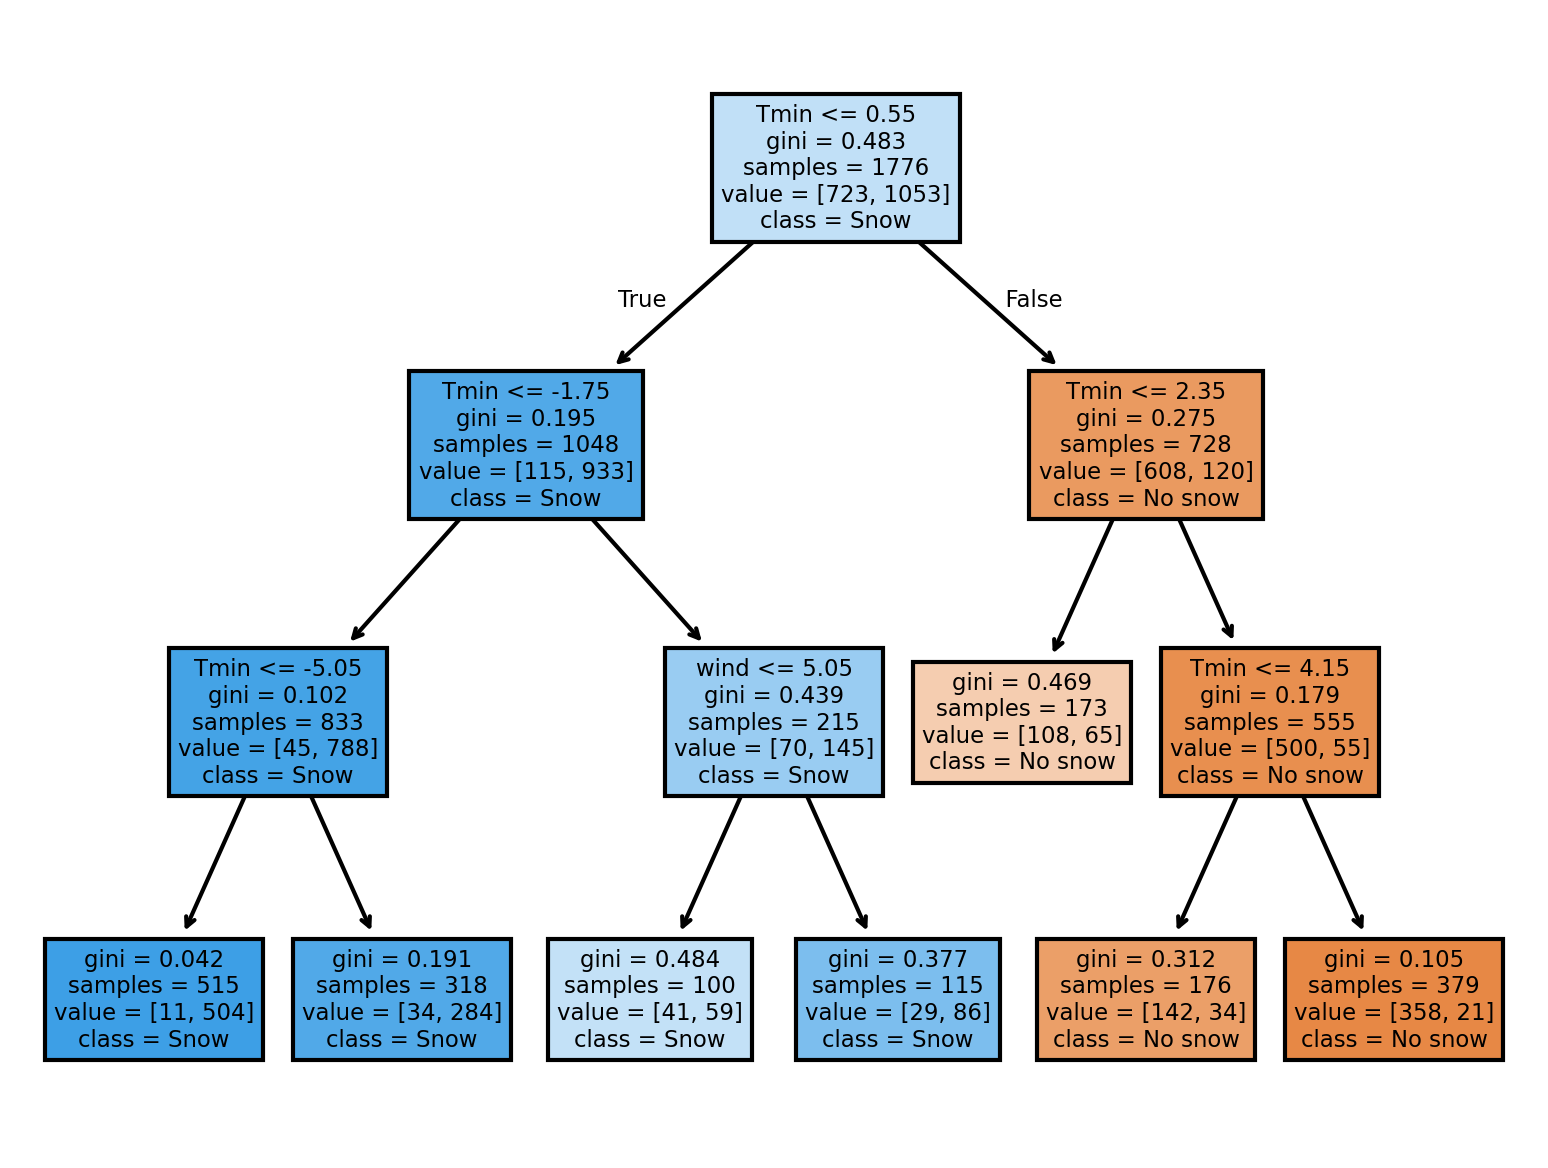

In [179]:
from sklearn import tree
clf = tree.DecisionTreeClassifier(max_depth=3, min_samples_leaf=100)
clf = clf.fit(X_train, y_train)

fig, ax = plt.subplots(dpi=300)
tree.plot_tree(clf, feature_names=X.columns,ax=ax, class_names=['No snow','Snow'],filled=True);

/opt/conda/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# Evaluate the model on test data

[Text(0.5, 0, 'No Snow'), Text(1.5, 0, 'Snow')]

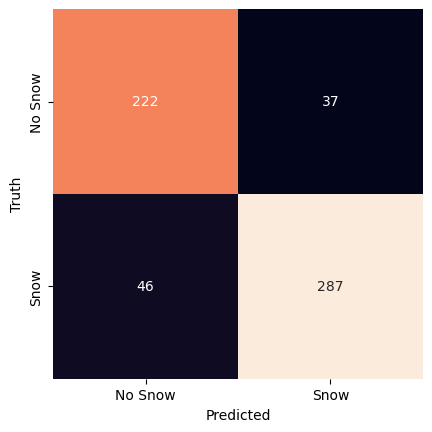

In [31]:
matrix = confusion_matrix(y_test, clf.predict(X_test))
fig, ax = plt.subplots()
sns.heatmap(matrix, square=True, cbar=False, annot=True, fmt='.0f',ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Truth')
ax.set_yticklabels(['No Snow','Snow'])
ax.set_xticklabels(['No Snow','Snow'])

In [32]:
y_train.value_counts()

Snow_presence
1    1069
0     707
Name: count, dtype: int64

In [33]:
from sklearn import ensemble
clf = ensemble.RandomForestClassifier(class_weight={1:1069, 0:707})
clf = clf.fit(X_train, y_train)

[Text(0.5, 0, 'No Snow'), Text(1.5, 0, 'Snow')]

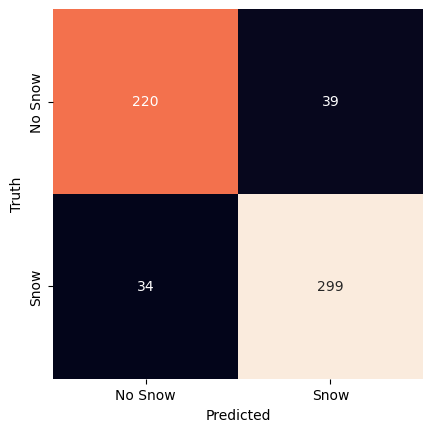

In [34]:
matrix = confusion_matrix(y_test, clf.predict(X_test))
fig, ax = plt.subplots()
sns.heatmap(matrix, square=True, cbar=False, annot=True, fmt='.0f',ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Truth')
ax.set_yticklabels(['No Snow','Snow'])
ax.set_xticklabels(['No Snow','Snow'])

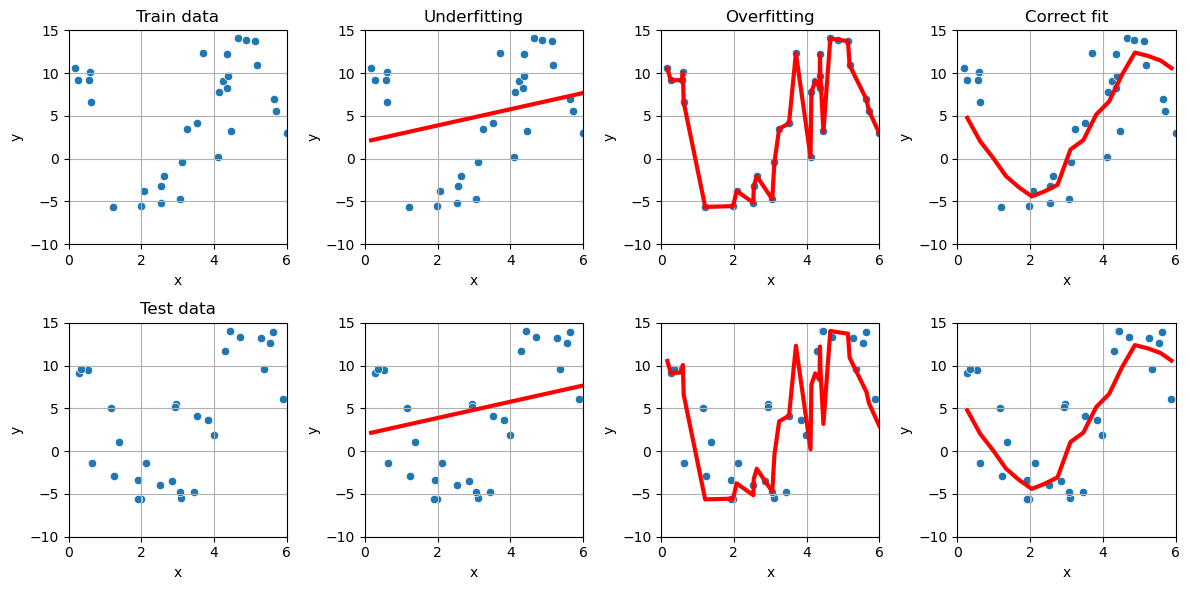

In [249]:
df_ = pd.DataFrame(dict(x=np.linspace(0.1,6,500)))
df_['y'] = 4*np.tanh(df_.x) + 10*np.cos(df_.x+2*np.random.random(df_.x.size))+ .3*np.random.random(df_.x.size)
np.random.seed(42)

train_data = df_.sample(30, random_state=12)
test_data = df_.sample(30, random_state=0)

fig, axs=plt.subplots(2,4,figsize=(12,6))
for k in range(4):
    sns.scatterplot(train_data, x='x',y='y',ax=axs[0,k])
    sns.scatterplot(test_data, x='x',y='y',ax=axs[1,k])

from sklearn.linear_model import LinearRegression
lr = LinearRegression().fit(train_data[['x']], train_data[['y']])
train_data['linear_y'] = lr.predict(train_data[['x']])
sns.lineplot(train_data, x='x',y='linear_y', color='red', ax=axs[0,1], lw=3)
sns.lineplot(train_data, x='x',y='linear_y', color='red', ax=axs[1,1], lw=3)
sns.lineplot(train_data, x='x',y='y', color='red', ax=axs[0,2], lw=3)
sns.lineplot(train_data, x='x',y='y', color='red', ax=axs[1,2], lw=3)
sns.lineplot(df_.groupby(30*(df_.index//30)).mean(), x='x',y='y', color='red', ax=axs[0,3], lw=3)
sns.lineplot(df_.groupby(30*(df_.index//30)).mean(), x='x',y='y', color='red', ax=axs[1,3], lw=3)


for ax in axs.flat:
    ax.grid()
    ax.set_xlim(0,6)
    ax.set_ylim(-10,15)

axs[0,0].set_title('Train data')
axs[1,0].set_title('Test data')
axs[0,1].set_title('Underfitting')
axs[0,2].set_title('Overfitting')
axs[0,3].set_title('Correct fit')
plt.tight_layout()
